# Decision Trees Recap

Now is the perfect time to recap everything you have learned about decision trees. 

By the way, this can also be done as a pair exercise! Explaining the concepts to another person allows you to challenge and deepen your own understanding. 
Here are two ways to do this:
- a. we have created a sketch board where you can answer the questions together (you can both write on the same board).
- b. you answer the questions together in this notebook.

For a: In this repo, we have added an [excalidraw file](assets/decision_tree_recap.excalidraw). You can open this at [excalidraw.com](https://excalidraw.com/) and start a "live collaboration" session with your Pair Programmer. Start with explaining the Decision Tree Algorithm to each other in 2 minutes.


For b: Here are the questions:

1. The typical interview question:
<br />
<br />
Q: What is your favorite algorithm?
<br />
A: Decision trees
<br />
Q: Can you explain it to me in 2 minutes?
<br />
<br />
2. Explain the tree terminology: node, threshold, leaf, and stump.
<br />
<br />
3. Explain how to determine the optimal split 
<br />
<br />
4. Explain what the Gini impurity is and how to calculate it
<br />
<br />
5. Explain how to make predictions for unseen data (especially with an impure leaf)
<br />
<br />
6. How to avoid overfitting decision trees
<br />
<br />
7. What are the advantages and disadvantages of decision trees?
<br />
<br />


8. Here is a sample data set. Please check your understanding and let's grow a tree on paper! 

    Data:
    
    |X1|X2 |Y|
    |---|---|---|
    |15|35|1|
    |17|45|1|
    |24|37|1|
    |24|37|1|
    |23|45|2|
    |27|37|2|
    |33|37|2|
    |27|34|3|
    |28|33|3|


    Remember how to decide on the next division to be made.
    - Please calculate the Gini gain for each step. 
    - You can also draw a scatterplot with all data points on paper and add the decision boundaries. 
    - Do you think there would have been another way to split the tree to get the same Gini gain at each step?
    - To evaluate your grown tree, simply use the data and train a decision tree with Sklearn and plot your tree as you have seen in the notebook before.

If you want to read up on how to make the next decision in your tree and how to calculate the Gini gain, here is a good resource: [Decision Tree from Scratch in Python](https://medium.com/data-science/decision-tree-from-scratch-in-python-46e99dfea775). **Only the text!**

### 1. Decision trees in two minutes

A decision tree splits the data by asking one yes/no question at a time. It looks at every feature and every possible cut-point, and picks the single question that best separates the classes. It then repeats that on each of the two resulting groups, and again on their groups, until it stops — either because a group is pure, or because a stopping rule kicks in.

To classify a new data point you drop it in at the top and follow the answers down until you reach a leaf. The prediction is the majority class of the training examples that landed there.

Trees are popular because you can read the logic straight off the diagram, they handle numeric and categorical data, and they need no feature scaling.

### 2. Tree terminology

- **Node** — a point in the tree where a question is asked. The **root node** is the first one, and it sees all the data.
- **Threshold** — the cut-off used in that question. In `X2 <= 34.5` the threshold is 34.5. It is normally the midpoint between two adjacent observed values.
- **Leaf** — a node with no children, where a prediction is made instead of a question. Also called a terminal node.
- **Stump** — a tree with exactly one split: a root plus two leaves, depth 1. Deliberately weak, which is why boosting algorithms such as AdaBoost use stumps as their building blocks.

### 3. Determining the optimal split

For every feature, sort the values and treat every midpoint between adjacent values as a candidate threshold. For each candidate, split the data and measure how impure the two resulting groups are, weighted by how many samples each holds. The best split is the one that reduces impurity the most relative to the parent — the largest **Gini gain**.

This is a **greedy** search: the tree takes the best split available right now, without checking whether a worse split now would open up better splits later. That is why the resulting tree is not guaranteed to be the globally optimal one.

### 4. Gini impurity

Gini impurity measures how mixed a group is — the probability that two randomly drawn samples from it belong to different classes. Zero means pure: every sample is the same class.

$$G = 1 - \sum_i p_i^2$$

where $p_i$ is the proportion of class $i$ in the group.

**Example** — 9 samples: 4 of class 1, 3 of class 2, 2 of class 3.

$$G = 1 - (4/9)^2 - (3/9)^2 - (2/9)^2 = 1 - \frac{16}{81} - \frac{9}{81} - \frac{4}{81} = \frac{52}{81} = 0.6420$$

**Gini gain** is the parent's impurity minus the weighted average of the children's impurities:

$$\text{gain} = G_{parent} - \left(\frac{n_{left}}{n} G_{left} + \frac{n_{right}}{n} G_{right}\right)$$

### 5. Making predictions, including from an impure leaf

Follow the questions down from the root until you land in a leaf.

- The predicted **class** is the majority class of the training samples in that leaf.
- The predicted **probability** for each class is the fraction of that leaf's training samples belonging to it. A leaf holding 30 samples of class A and 10 of class B predicts class A with probability 0.75.

This explains a result from the previous notebook: an unconstrained tree grows until every leaf is pure, so every leaf is 100% one class and the only probabilities it can output are 0 and 1. With no gradation there are only three usable thresholds, which is why its ROC "curve" came out as a triangle. Forcing a minimum number of samples per leaf makes leaves mixed, produces a spread of probabilities, and yields a real curve.

### 6. Avoiding overfitting

- **Pre-pruning** — constrain the tree as it grows: `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes`, `min_impurity_decrease`.
- **Post-pruning** — grow the tree fully, then cut back branches that do not improve performance. In scikit-learn this is `ccp_alpha` (cost-complexity pruning).
- **Detect it first** — compare training and test scores. A large gap between them is overfitting made visible.
- **Use ensembles** — random forests and boosting average many trees so that individual trees' overfitting partly cancels out.

The previous notebook gives concrete evidence: an unconstrained tree scored **1.0 on train and 0.6587 on test**, a gap of 0.34. Setting `max_depth=15` and `min_samples_leaf=100` gave **0.8658 on train and 0.8339 on test** — a gap of 0.03, and a far better test score.

### 7. Advantages and disadvantages

| Advantages | Disadvantages |
|---|---|
| Easy to interpret and explain to non-technical stakeholders | Overfit badly if left unconstrained |
| No feature scaling or normalisation required | Unstable — small changes in the data can produce a very different tree |
| Handles numeric and categorical features together | Greedy splitting gives no guarantee of the globally best tree |
| Captures non-linear relationships without transformation | Gini importance is biased toward features with many distinct values |
| Fast to train and to predict | Struggles with diagonal boundaries — splits are axis-parallel, so a sloped boundary needs many stair-steps |
| Feature importances come for free | Can produce biased trees when one class dominates |

### 8. Growing a tree by hand

**Root node.** 9 samples: four of class 1, three of class 2, two of class 3.

$$G = 1 - (4/9)^2 - (3/9)^2 - (2/9)^2 = 0.6420$$

All candidate splits, ranked by gain:

| Split | nL | nR | Gini L | Gini R | Weighted | Gain |
|---|---|---|---|---|---|---|
| **X2 ≤ 34.5** | 2 | 7 | 0.0000 | 0.4898 | 0.3810 | **0.2610** |
| X1 ≤ 25.5 | 5 | 4 | 0.3200 | 0.5000 | 0.4000 | 0.2420 |
| X2 ≤ 36.0 | 3 | 6 | 0.4444 | 0.5000 | 0.4815 | 0.1605 |
| X1 ≤ 20.0 | 2 | 7 | 0.0000 | 0.6531 | 0.5079 | 0.1340 |
| X2 ≤ 33.5 | 1 | 8 | 0.0000 | 0.5938 | 0.5278 | 0.1142 |

Winner: **X2 ≤ 34.5**. The arithmetic in full:

- Left (2 rows, both class 3): $G = 1 - (2/2)^2 = 0$
- Right (7 rows, 4×class 1 + 3×class 2): $G = 1 - (4/7)^2 - (3/7)^2 = 24/49 = 0.4898$
- Weighted: $(2/9)(0) + (7/9)(0.4898) = 0.3810$
- Gain: $0.6420 - 0.3810 = 0.2610$

The left side is pure, so it becomes a **leaf predicting class 3**.

**Right child** — 7 samples, $G = 0.4898$:

| Split | nL | nR | Gini L | Gini R | Weighted | Gain |
|---|---|---|---|---|---|---|
| **X1 ≤ 25.5** | 5 | 2 | 0.3200 | 0.0000 | 0.2286 | **0.2612** |
| X1 ≤ 20.0 | 2 | 5 | 0.0000 | 0.4800 | 0.3429 | 0.1469 |
| X1 ≤ 30.0 | 6 | 1 | 0.4444 | 0.0000 | 0.3810 | 0.1088 |
| X2 ≤ 36.0 | 1 | 6 | 0.0000 | 0.5000 | 0.4286 | 0.0612 |

Winner: **X1 ≤ 25.5**. The right side is pure class 2 → **leaf**.

**Next node** — 5 samples (4×class 1, 1×class 2), $G = 0.3200$. Best split is **X2 ≤ 41.0** with a gain of 0.1200, leaving one final split on **X1 ≤ 20.0**.

**Resulting tree:**

```
X2 <= 34.5 ?
├── yes → class 3
└── no  → X1 <= 25.5 ?
          ├── yes → X2 <= 41.0 ?
          │         ├── yes → class 1
          │         └── no  → X1 <= 20.0 ?
          │                   ├── yes → class 1
          │                   └── no  → class 2
          └── no  → class 2
```

**Was there another way to split with the same Gini gain?**

There were no exact ties at any level in this dataset, but two things are worth noting.

First, **the threshold itself is arbitrary within a gap**. X2 ≤ 34.5 is simply the midpoint between the observed values 34 and 35 — any cut between them produces an identical split and an identical gain. The value 34.5 is convention, not a property of the data.

Second, **the root was close to a tie**. X1 ≤ 25.5 scored 0.2420 against the winner's 0.2610, and that same split is chosen at the very next level anyway. This shows how arbitrary greedy ordering can be: a small change in the data could have flipped the order of the first two questions and produced a different-looking tree that classifies just as well.

**Verification.** Training a scikit-learn `DecisionTreeClassifier` on the same data reproduces this tree exactly — `X2 <= 34.5` → `X1 <= 25.5` → `X2 <= 41.0` → `X1 <= 20.0`, depth 4, 5 leaves, 100% training accuracy.

Plotting the decision boundaries on a scatter plot shows every boundary is either horizontal or vertical. That is the axis-parallel limitation from question 7, visible on the page.

|--- X2 <= 34.50
|   |--- class: 3
|--- X2 >  34.50
|   |--- X1 <= 25.50
|   |   |--- X2 <= 41.00
|   |   |   |--- class: 1
|   |   |--- X2 >  41.00
|   |   |   |--- X1 <= 20.00
|   |   |   |   |--- class: 1
|   |   |   |--- X1 >  20.00
|   |   |   |   |--- class: 2
|   |--- X1 >  25.50
|   |   |--- class: 2

depth: 4 | leaves: 5 | train accuracy: 1.0


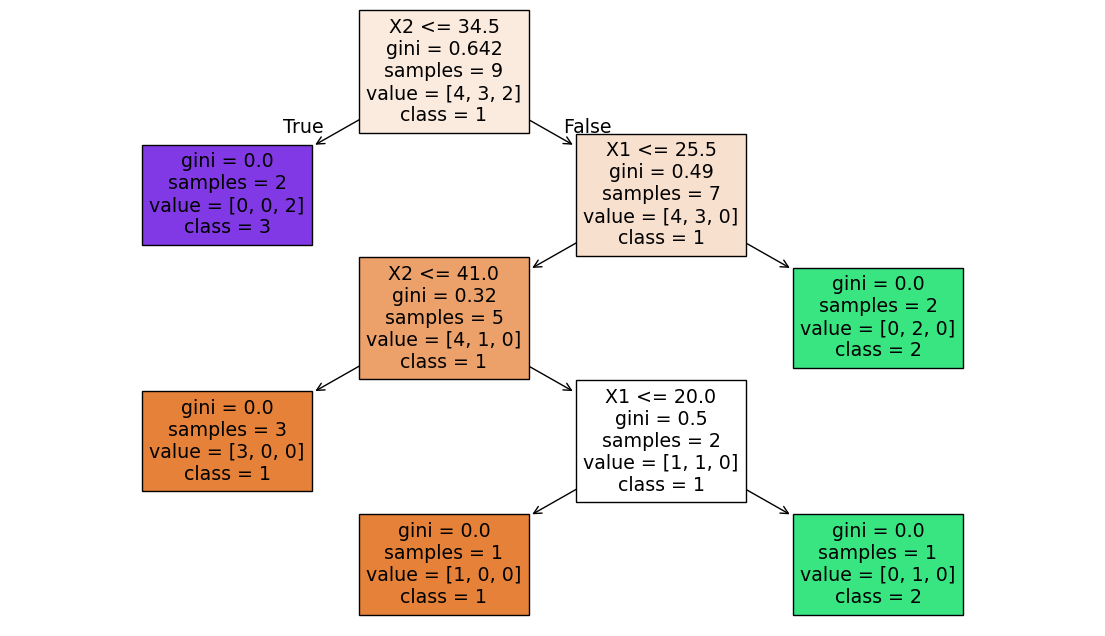

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

X = np.array([[15,35],[17,45],[24,37],[24,37],[23,45],[27,37],[33,37],[27,34],[28,33]], dtype=float)
y = np.array([1, 1, 1, 1, 2, 2, 2, 3, 3])

clf = DecisionTreeClassifier(random_state=42).fit(X, y)

print(export_text(clf, feature_names=["X1", "X2"]))
print(f"depth: {clf.tree_.max_depth} | leaves: {clf.tree_.n_leaves} | train accuracy: {clf.score(X, y)}")

fig = plt.figure(figsize=(14, 8))
plot_tree(clf, feature_names=["X1", "X2"], class_names=["1", "2", "3"], filled=True)
plt.show()

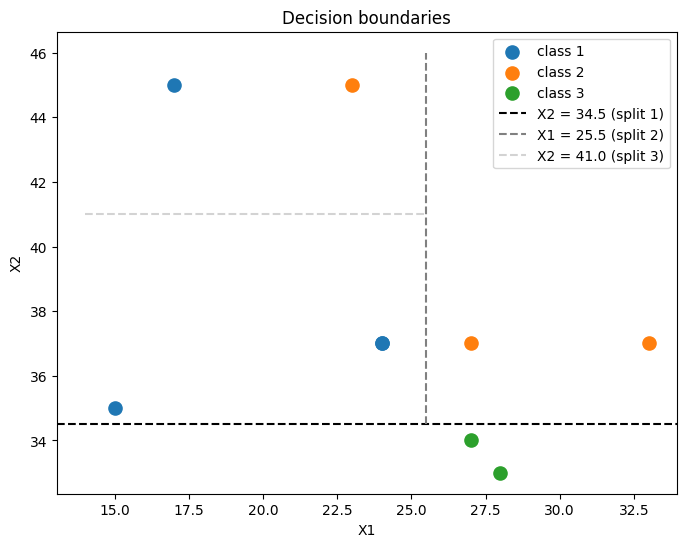

In [4]:
plt.figure(figsize=(8, 6))
for cls, colour in zip([1, 2, 3], ["tab:blue", "tab:orange", "tab:green"]):
    mask = y == cls
    plt.scatter(X[mask, 0], X[mask, 1], c=colour, s=90, label=f"class {cls}")

plt.axhline(34.5, color="black", linestyle="--", label="X2 = 34.5 (split 1)")
plt.vlines(25.5, ymin=34.5, ymax=46, color="grey", linestyle="--", label="X1 = 25.5 (split 2)")
plt.hlines(41.0, xmin=14, xmax=25.5, color="lightgrey", linestyle="--", label="X2 = 41.0 (split 3)")

plt.xlabel("X1"); plt.ylabel("X2"); plt.legend(); plt.title("Decision boundaries")
plt.show()


---
## Extras

If you haven't had enough of decision trees yet, here are a few more ways to delve further into the topic:
1. get deep into the code of building a dec tree from scratch in python
2. get into the [theory of building trees recursively](https://cr.yp.to/2005-261/bender2/DT.pdf) (same as nr. 1 but without code)
3. watch [another decision tree lecture](https://www.youtube.com/watch?v=wr9gUr-eWdA&list=PLEny7y9mZcaxFAyivwT2nwIEvfHAzFdX9&index=11), which covers splitting criteria (entropy, gini etc.) and regression trees. The part about decision trees ends after 1h.

### To Nr 1
You will see that in the [blogpost above](https://medium.com/data-science/decision-tree-from-scratch-in-python-46e99dfea775) there is also a Python implementation of the Decision Tree Algorithm at the end.
This is an **extra**: If you want to dive deep into how to build a decision tree **recursively** in Python, check out the following code. 

This code is built like a python script: it starts with the definitions of the classes and their methods. At the very bottom the implemented Decision Tree Classifier is then applied to the iris dataset.




In [1]:
"""Implementation of the CART algorithm to train decision tree classifiers."""
import numpy as np


class Node:
    def __init__(self, predicted_class):
        self.predicted_class = predicted_class
        self.feature_index = 0
        self.threshold = 0
        self.left = None
        self.right = None


class DecisionTreeClassifier:
    def __init__(self, max_depth: int | None = None):
        self.max_depth = max_depth

    def fit(self, X, y):
        """Build decision tree classifier."""
        self.n_classes_ = len(set(y))
        self.n_features_ = X.shape[1]
        self.tree_ = self._grow_tree(X, y)

    def predict(self, X):
        return [self._predict(inputs) for inputs in X]

    def _best_split(self, X, y):
        """Find the best split for a node.
        "Best" means that the average impurity of the two children, weighted by their
        population, is the smallest possible. Additionally it must be less than the
        impurity of the current node.
        To find the best split, we loop through all the features, and consider all the
        midpoints between adjacent training samples as possible thresholds. We compute
        the Gini impurity of the split generated by that particular feature/threshold
        pair, and return the pair with smallest impurity.
        Returns:
            best_idx: Index of the feature for best split, or None if no split is found.
            best_thr: Threshold to use for the split, or None if no split is found.
        """
        # Need at least two elements to split a node.
        m = y.size
        if m <= 1:
            return None, None

        # Count of each class in the current node.
        num_parent = [np.sum(y == c) for c in range(self.n_classes_)]

        # Gini of current node.
        best_gini = 1.0 - sum((n / m) ** 2 for n in num_parent)
        best_idx, best_thr = None, None

        # Loop through all features.
        for idx in range(self.n_features_):
            # Sort data along selected feature.
            thresholds, classes = zip(*sorted(zip(X[:, idx], y)))

            # We could actually split the node according to each feature/threshold pair
            # and count the resulting population for each class in the children, but
            # instead we compute them in an iterative fashion, making this for loop
            # linear rather than quadratic.
            num_left = [0] * self.n_classes_
            num_right = num_parent.copy()
            for i in range(1, m):
                c = classes[i - 1]
                num_left[c] += 1
                num_right[c] -= 1
                gini_left = 1.0 - sum(
                    (num_left[x] / i) ** 2 for x in range(self.n_classes_)
                )
                gini_right = 1.0 - sum(
                    (num_right[x] / (m - i)) ** 2 for x in range(self.n_classes_)
                )

                # The Gini impurity of a split is the weighted average of the Gini
                # impurity of the children.
                gini = (i * gini_left + (m - i) * gini_right) / m

                # The following condition is to make sure we don't try to split two
                # points with identical values for that feature, as it is impossible
                # (both have to end up on the same side of a split).
                if thresholds[i] == thresholds[i - 1]:
                    continue

                if gini < best_gini:
                    best_gini = gini
                    best_idx = idx
                    best_thr = (thresholds[i] + thresholds[i - 1]) / 2

        return best_idx, best_thr

    def _grow_tree(self, X, y, depth: int = 0):
        """Build a decision tree by recursively finding the best split."""
        # Population for each class in current node. The predicted class is the one with
        # largest population.
        num_samples_per_class = [np.sum(y == i) for i in range(self.n_classes_)]
        predicted_class = np.argmax(num_samples_per_class)
        node = Node(predicted_class=predicted_class)

        # Split recursively until maximum depth is reached.
        if self.max_depth is None or depth < self.max_depth:
            idx, thr = self._best_split(X, y)
            if idx is not None:
                indices_left = X[:, idx] < thr
                X_left, y_left = X[indices_left], y[indices_left]
                X_right, y_right = X[~indices_left], y[~indices_left]
                node.feature_index = idx
                node.threshold = thr
                node.left = self._grow_tree(X_left, y_left, depth + 1)
                node.right = self._grow_tree(X_right, y_right, depth + 1)
        return node

    def _predict(self, inputs):
        """Predict class for a single sample."""
        node = self.tree_
        while node.left:
            if inputs[node.feature_index] < node.threshold:
                node = node.left
            else:
                node = node.right
        return node.predicted_class


if __name__ == "__main__":
    from sklearn.datasets import load_iris

    # Load data.
    dataset = load_iris()
    X, y = dataset.data, dataset.target  # pylint: disable=no-member

    # train model
    clf = DecisionTreeClassifier(max_depth=1)
    clf.fit(X, y)

    # predict on one sample
    print(clf.predict([[0, 0, 5, 1.5]]))

[np.int64(1)]


### What's done when running clf.fit()

If you're feeling a little lost in the code and recursive tree construction, hopefully this image can help you a bit with how the tree was built. Of course, it is only an example, including some possibilities why further splits didn't happen.

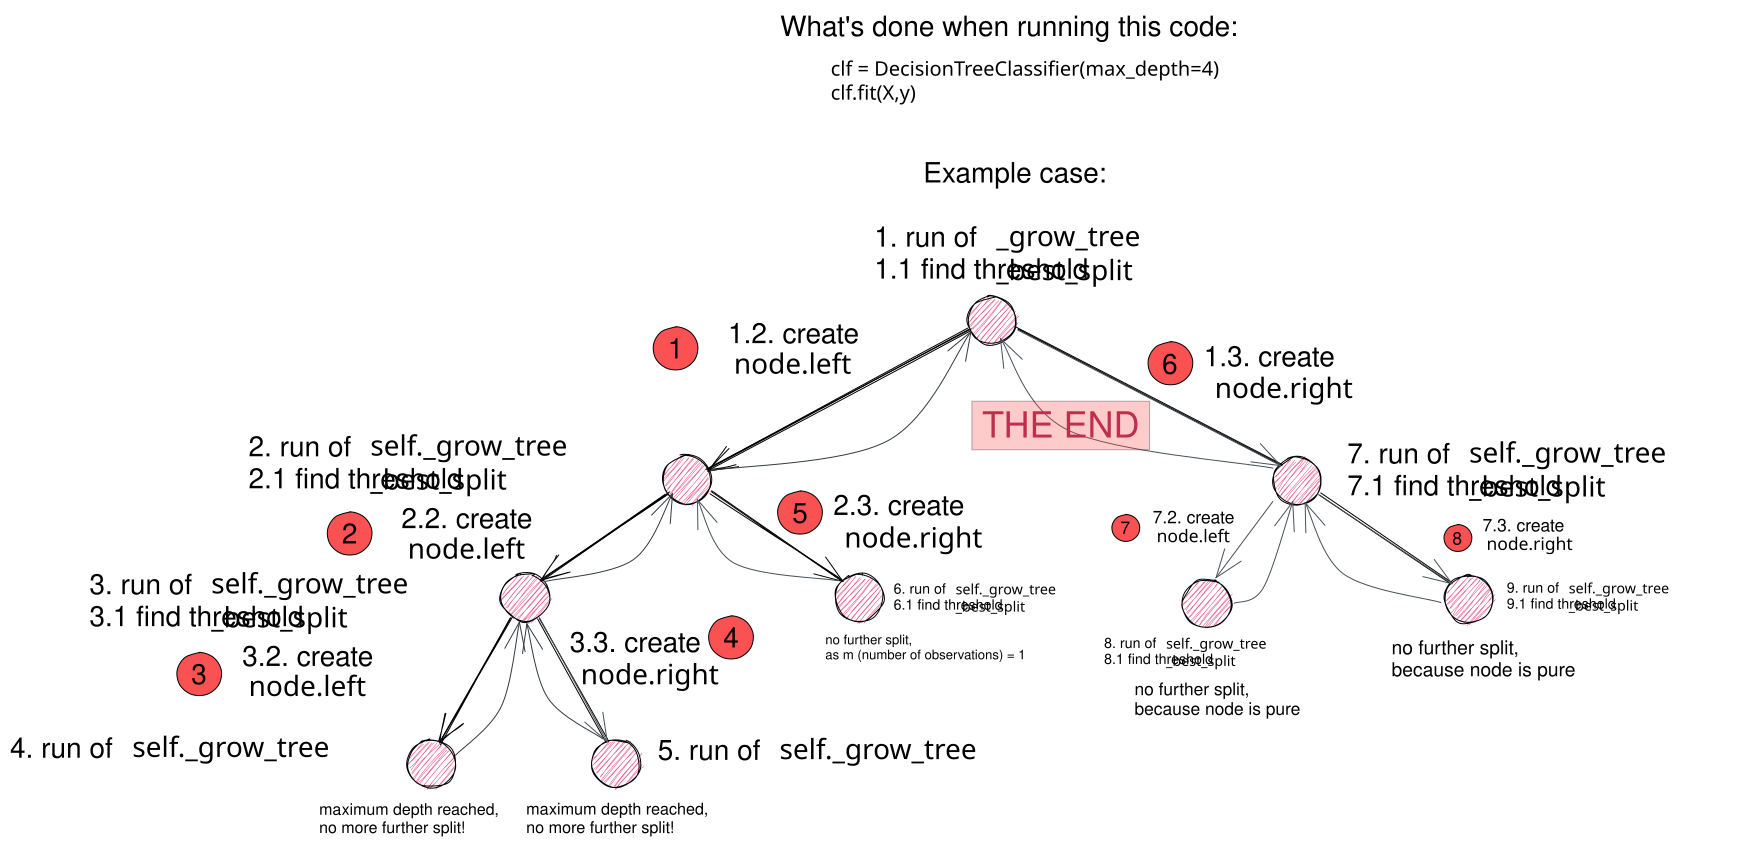

In [2]:
from IPython.display import SVG

SVG(filename="assets/decision_tree.svg")